In [4]:
import pandas as pd

In [5]:
df = pd.read_csv(r"C:\\Users\\ASUS\\Downloads\\telecom\\WA_Fn-UseC_-Telco-Customer-Churn.csv")

In [4]:
df.head(2)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [4]:
import pandas as pd

df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Заполняем пустые значения нулями
df['TotalCharges'] = df['TotalCharges'].fillna(0)

# Проверяем, что тип данных изменился
print(df['TotalCharges'].dtype)


float64


In [9]:
# 1. Общий отток в компании
print(f"Общий отток: {(df['Churn'] == 'Yes').mean() * 100:.2f}%")

# 2. Средний чек в месяц
print(f"Средний доход с пользователя (ARPU): {df['MonthlyCharges'].mean():.2f} $")

# 3. Как тип контракта влияет на отток?
print("\nОтток в зависимости от типа контракта:")
print((df['Churn'] == 'Yes').groupby(df['Contract']).mean() * 100)



Общий отток: 26.54%
Средний доход с пользователя (ARPU): 64.76 $

Отток в зависимости от типа контракта:
Contract
Month-to-month    42.709677
One year          11.269518
Two year           2.831858
Name: Churn, dtype: float64


Можем видеть клиенты покупающие 2 годовую подписку неохотно уходит от сервиса, так же как и покупающие  годовую подписку. Клиенты покупающие месячную подиску подозрительно больше, почти 43%. Будем предсказать в будущем как это изменится

Text(0, 0.5, 'Количество клиентов')

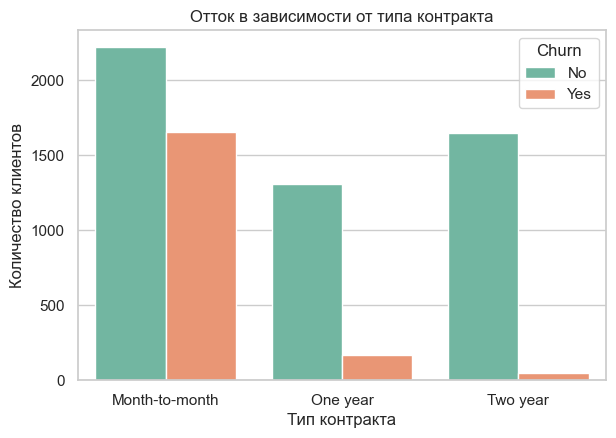

In [12]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# Настройка стиля графиков
sns.set_theme(style="whitegrid")
plt.figure(figsize=(15, 10))

# Зависимость оттока от типа контракта (Contract)
plt.subplot(2, 2, 1)
sns.countplot(x="Contract", hue="Churn", data=df, palette="Set2")
plt.title("Отток в зависимости от типа контракта")
plt.xlabel("Тип контракта")
plt.ylabel("Количество клиентов")




В графике можем наглядно увидеть то что сказано выше

Text(0, 0.5, 'Количество клиентов')

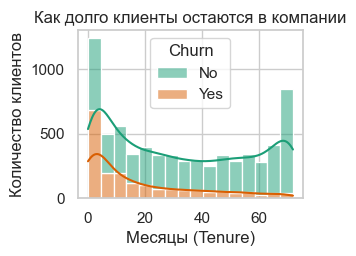

In [14]:
#  Распределение времени жизни клиента
plt.subplot(2, 2, 4)
sns.histplot(
    x="tenure", hue="Churn", data=df, multiple="stack", kde=True, palette="Dark2"
)
plt.title("Как долго клиенты остаются в компании")
plt.xlabel("Месяцы (Tenure)")
plt.ylabel("Количество клиентов")

Половина клентов уходят уже в начале месяца. Дальше в большинстве случаев останутся

Text(0, 0.5, 'Способ оплаты')

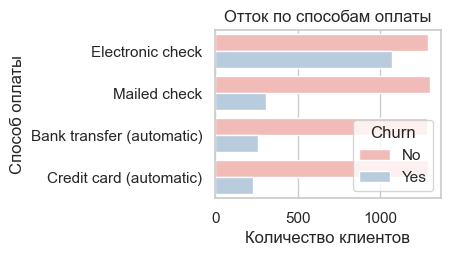

In [12]:
# ГРАФИК 3: Влияние способа оплаты (PaymentMethod) на отток
plt.subplot(2, 2, 3)
sns.countplot(y="PaymentMethod", hue="Churn", data=df, palette="Pastel1")
plt.title("Отток по способам оплаты")
plt.xlabel("Количество клиентов")
plt.ylabel("Способ оплаты")

Клиенты уходят в большинстве случаев когда придется оплачивать через электронно, что может быть неудобно. Поэтому предпочитают автоматический трансфер

C:\Users\ASUS\AppData\Local\Temp\ipykernel_20936\1686949069.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="Churn", y="MonthlyCharges", data=df, palette="Accent")


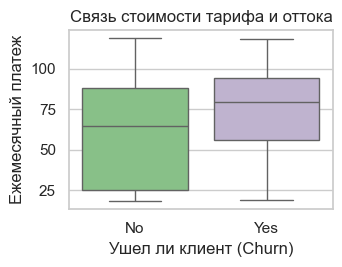

In [13]:


# ГРАФИК 4: Ежемесячные платежи (MonthlyCharges) и отток
plt.subplot(2, 2, 4)
sns.boxplot(x="Churn", y="MonthlyCharges", data=df, palette="Accent")
plt.title("Связь стоимости тарифа и оттока")
plt.xlabel("Ушел ли клиент (Churn)")
plt.ylabel("Ежемесячный платеж")

plt.tight_layout()
plt.show()

Когда стоимость тарифа начинаетя от 55 отток клентов тоже начинается. Наибольший отток виден когда тариф состовляет около 75-85 долларов 

In [18]:
a={'Yes':1,'No':0}
df['Churn_numeric'] = df['Churn'].map(a)


In [13]:
import pandas as pd

senior_analysis = df.groupby('SeniorCitizen').agg(
    Процент_Оттока=('Churn_numeric', lambda x: round(x.mean() * 100, 2)),
    Средний_Чек=('MonthlyCharges', 'mean'),
    Всего_Клиентов=('customerID', 'count')
)
senior_analysis

,Процент_Оттока,Средний_Чек,Всего_Клиентов
SeniorCitizen,,,
0,23.61,61.847441,5901
1,41.68,79.820359,1142


Среди пожилых клиентов процент оттока выше и можем увидеть что средний чек у них тоже выше. и займет около 15% процентов от всех клиентов.

In [14]:
#Правда ли что без тезподержки клиенты уходят чаще?
internet_analysis = df.groupby(['InternetService', 'TechSupport']).agg(
    Процент_Оттока=('Churn_numeric', lambda x: round(x.mean() * 100, 2)),
    Всего_Клиентов=('customerID', 'count')
)
internet_analysis

Процент_Оттока  Всего_Клиентов
InternetService TechSupport                                        
DSL             No                            27.76            1243
                Yes                            9.68            1178
Fiber optic     No                            49.37            2230
                Yes                           22.63             866
No              No internet service            7.40            1526

70% всех клиентов состовляет сервис в Fiber Optic. Половина клиентов уходят из за отсутствие или без оказание техпомощи вовремя. и 23% уходят после оказание помощи. Это может быть нормой или нет, зависит от компании

In [16]:
#Сравниваем клентов по статусу партеров
df['Family_Status'] = df['Partner'] + "_" + df['Dependents']
family_analysis = df.groupby('Family_Status').agg(
    Процент_Оттока=('Churn_numeric', lambda x: round(x.mean() * 100, 2)),
    Средний_Срок_Жизни_Месяцев=('tenure', 'mean')
)
family_analysis

,Процент_Оттока,Средний_Срок_Жизни_Месяцев
Family_Status,,
No_No,34.24,23.303354
No_Yes,21.33,23.853186
Yes_No,25.41,42.709014
Yes_Yes,14.24,41.364208


Когда у клиента нет детей и партнера он в 2 раза охотнее уходит от текущего тарифа, продолжительность также в 2 раза меньше. Клиенты у который есть партнер по времени в 2 раза больше останется чем партнеры с детьми. Можем приити к выводу что партнеры намного больше влияет на то что клиент останется чем дети

In [17]:
!pip install scikit-learn

In [18]:
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split

# --- ШАГ 3.1: Подготовка данных ---
# Выбираем ключевые признаки для прогноза (можете добавить другие)
features = [
    "SeniorCitizen",
    "tenure",
    "MonthlyCharges",
    "TotalCharges",
    "Contract",
    "InternetService",
    "TechSupport",
]
X = df[features].copy()

# Переводим текстовые колонки (Contract, InternetService, TechSupport) в числа (0 и 1)
X = pd.get_dummies(X, columns=["Contract", "InternetService", "TechSupport"], drop_first=True)

# Целевая переменная (что предсказываем)
y = df["Churn_numeric"]

# Разделяем данные: 80% на обучение модели, 20% на проверку качества
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# --- ШАГ 3.2: Обучение модели ---
model = RandomForestClassifier(n_estimators=100, random_state=42, max_depth=10)
model.fit(X_train, y_train)

# --- ШАГ 3.3: Проверка качества ---
predictions = model.predict(X_test)

print("=== ОТЧЕТ О КАЧЕСТВЕ МОДЕЛИ ===")
print(classification_report(y_test, predictions))

# --- ШАГ 3.4: Что важнее всего для прогноза? ---
importances = pd.Series(model.feature_importances_, index=X.columns).sort_values(
    ascending=False
)
print("\n=== ВАЖНОСТЬ ПРИЗНАКОВ ДЛЯ МОДЕЛИ ===")
print(importances)


=== ОТЧЕТ О КАЧЕСТВЕ МОДЕЛИ ===
              precision    recall  f1-score   support

           0       0.83      0.89      0.86      1035
           1       0.63      0.51      0.56       374

    accuracy                           0.79      1409
   macro avg       0.73      0.70      0.71      1409
weighted avg       0.78      0.79      0.78      1409


=== ВАЖНОСТЬ ПРИЗНАКОВ ДЛЯ МОДЕЛИ ===
TotalCharges                       0.243296
tenure                             0.236905
MonthlyCharges                     0.202684
InternetService_Fiber optic        0.110227
Contract_Two year                  0.075186
Contract_One year                  0.041237
InternetService_No                 0.027951
TechSupport_Yes                    0.024933
TechSupport_No internet service    0.018997
SeniorCitizen                      0.018586
dtype: float64


Это модель случайного леса для предсказания оттока на 7000 клиентов. Модель находит 51% уходящих абонентов с точностью 63%. Анализ важности признаков показал, что ключевыми факторами оттока являются финансовые метрики (срок жизни и затраты), а также тип интернета — пользователи оптоволокна (Fiber optic) уходят аномально часто. Я бы рекомендовал бизнесу проверить качество связи на этом типе оборудования и сфокусироваться на удержании новых клиентов в первые месяцы